# Xenium spatial analysis
### **Author:** Nathalie Nataren
### **Date:** 28/08/2025

**Description:** The purpose of this analysis is to analyse Xenium spatial data as part of the metastatic melanoma ICI therapy response study (VBCT lab). This workbook contains the analysis for a single Xenium sample, with details shown below.
**Sample:** ck_skin_res

**Settings**  

Cluster resolution=  0.3

PCs=  20

Nearest neighbours=  50

Lambda=  0.2

In [29]:
import anndata as ad
import os
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings("ignore") 

import scipy.sparse as sparse
from scipy.io import mmread
from scipy.stats import pearsonr, pointbiserialr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

import seaborn as sns
import scanpy as sc
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

import random
# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

scanpy==1.9.5 anndata==0.10.2 umap==0.5.4 numpy==1.24.4 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.3.1 statsmodels==0.14.0 igraph==0.11.2 pynndescent==0.5.10


## Load Xenium data
Allocate path to folder and the file name of the designated AnnaData Object (in `.h5ad` format) <br>

In [30]:
# Read in preprocessed AnnData file
dataset_name = "MF_skin_non_res_roi"
adata = ad.read_h5ad(f"data/xenium/raw_data/{dataset_name}.h5ad")
output_path = f"data/xenium/processed/{dataset_name}_xy.h5ad"
adata.obs_keys()

# Create 'xy' spatial coordinates from adata.obs
import numpy as np
adata.obsm['xy'] = np.vstack([adata.obs['x'], adata.obs['y']]).T

#adata.write(output_path)

### Create directories for processed and output data

In [31]:
# Create path for processed data
processed_path = f"data/xenium/processed/{dataset_name}"

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
else:
    print(f"Directory '{processed_path}' already exists.")


# Create path for output data
output_path = "data/xenium/output/{dataset_name}"

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
else:
    print(f"Directory '{output_path}' already exists.")


Directory 'data/xenium/processed/MF_skin_non_res_roi' already exists.
Directory 'data/xenium/output/{dataset_name}' already exists.


### Float size downcasting in .obsm (64 to 32 bit)
I down cast information in the .obsm slot to 32-bit floats in order to reduce the workload on RAM during analysis.

In [ ]:
# Function to check the float size of the adata.obsm data
def check_float(adata):
    for key in adata.obsm.keys():
        arr = adata.obsm[key]
    if isinstance(arr, np.ndarray):
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

check_float(adata)

In [ ]:
# Function to downcast adata.obsm to 32 bit and check that the resulting array is an N-dimensional array
def downcast_float(adata, float_type):
    float_type = np.dtype(float_type)
    for key in adata.obsm.keys():
        arr = adata.obsm[key]
    if isinstance(arr, np.ndarray) and np.issubdtype(arr.dtype, np.floating): #check if the array is an N-dimensional array
        adata.obsm[key] = arr.astype(float_type)
        
        print(f"{adata} object downcast to {float_type}")

downcast_float(adata, "float32")


AnnData object with n_obs × n_vars = 397292 × 304
    obs: 'nucleus_area', 'nCount_Xenium', 'nFeature_Xenium', 'segmentation_method', 'nCount_BlankCodeword', 'nFeature_BlankCodeword', 'nCount_ControlCodeword', 'nFeature_ControlCodeword', 'nCount_ControlProbe', 'nFeature_ControlProbe', 'x', 'y', 'cell_area', 'nCount_SCT', 'nFeature_SCT'
    var: 'names'
    obsm: 'spatial', 'xy' object downcast to float32


In [ ]:
# Check the float size of the adata.obsm data after downcasting to make sure the float type is correct
check_float(adata)

xy: shape=(397292, 2), dtype=float32


In [ ]:
# Write the downcast file to AnnData format 
import anndata as ad
adata.write_h5ad(
    filename = f"data/xenium/processed/{dataset_name}_float_32.h5ad",
    compression="gzip"
    )

In [ ]:
# Define File paths
file_path = os.path.join("data", "xenium", "processed")
adata_filename = f"{dataset_name}_float_32.h5ad"


In [ ]:
print(f"Looking for {os.path.join(file_path, adata_filename)}")
print(type(file_path)) 
print(type(adata_filename))

Looking for data/xenium/processed/MF_skin_non_res_roi_float_32.h5ad
<class 'str'>
<class 'str'>


### Loading anndata file or converting raw files to anndata format  (h5ad)

- If the specified anndata file is present in the directory, the annadata file `.h5ad` in the file path can be read directly by setting the `load_adata_directly` to `True` <br>
- Otherwise, if the `AnnData` file is not present, `load_data` can convert the raw data of GCM and locations in `.csv` format to `.h5ad` directly.

In [ ]:
from banksy_utils.load_data import load_adata, display_adata

# To either load data from .h5ad directly or convert raw data to .h5ad format
load_adata_directly = True

# Keys to specify coordinate indexes in the anndata Object
coord_keys = ('x', 'y', 'xy')

raw_y, raw_x, adata = load_adata(filepath=file_path, adata_filename=adata_filename, load_adata_directly=True, coord_keys=('x','y','xy'))

Looking for data/xenium/processed/MF_skin_non_res_roi_float_32.h5ad
Attemping to read Annadata directly
Anndata file successfully loaded!
Attempting to concatenate spatial x-y under adata.obsm[xy]
Concatenation success!


In [ ]:
print(adata.X)

  (1890, 0)	1.0
  (2958, 0)	1.0
  (4015, 0)	1.0
  (4129, 0)	1.0
  (4160, 0)	2.0
  (4278, 0)	1.0
  (4285, 0)	5.0
  (5864, 0)	1.0
  (7006, 0)	2.0
  (7263, 0)	1.0
  (7484, 0)	3.0
  (7800, 0)	1.0
  (8066, 0)	1.0
  (8724, 0)	1.0
  (8748, 0)	1.0
  (9052, 0)	1.0
  (9833, 0)	1.0
  (12186, 0)	1.0
  (12515, 0)	2.0
  (13551, 0)	3.0
  (13876, 0)	1.0
  (14601, 0)	1.0
  (14829, 0)	1.0
  (17376, 0)	1.0
  (18464, 0)	1.0
  :	:
  (391432, 303)	1.0
  (391446, 303)	1.0
  (392048, 303)	1.0
  (392223, 303)	1.0
  (392288, 303)	1.0
  (392334, 303)	1.0
  (392417, 303)	1.0
  (392664, 303)	2.0
  (393074, 303)	1.0
  (393297, 303)	1.0
  (393340, 303)	1.0
  (393663, 303)	1.0
  (393716, 303)	1.0
  (394112, 303)	1.0
  (394284, 303)	1.0
  (394295, 303)	1.0
  (394384, 303)	1.0
  (394720, 303)	1.0
  (395006, 303)	1.0
  (395026, 303)	1.0
  (395317, 303)	1.0
  (396148, 303)	1.0
  (396154, 303)	1.0
  (396491, 303)	1.0
  (396628, 303)	1.0


In [ ]:
# import inspect
# from banksy_utils.load_data import load_adata

# # Inspect the function signature to understand expected arguments
# print(inspect.signature(load_adata))

### Display Anndata Object
Use `display_adata` to show summary of anndata object

In [ ]:
# display_adata(adata)

### Preprocessing the Data using `Scanpy` 
We then preprocess the raw data as follows:

1. Making variable names unique (removing duplicate gene names)
2. Filtering out the mitochondria genes (`MT`)
3. We use `scanpy`'s built-in function `sc.pp.calculate_qc_metrics` and adding them in-place in the anndata object

In [ ]:
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calulates QC metrics and put them in place to the adata object
sc.pp.calculate_qc_metrics(adata, 
                           qc_vars=["mt"], 
                           log1p=True, 
                           inplace=True,
                           percent_top=[10,20]
                           )

### Get preview of the preprocessed data: 
Display the qc-metrics under its observations and variables 

In [ ]:
#display(adata.obs, adata.var)

## Visualize the histogram plot of `total_counts` and `n_genes` (Optional)
We can visualize the unfiltered and filtered histograms for `total_counts` and `n_genes` variables in the adata object <br> 

The filtered histograms are plotted after filtering by the upper threshold of total counts `total_counts_cuttoff`, the upper threshold of n_genes `n_genes_high_cutoff`, and the lower threshold of n_genes

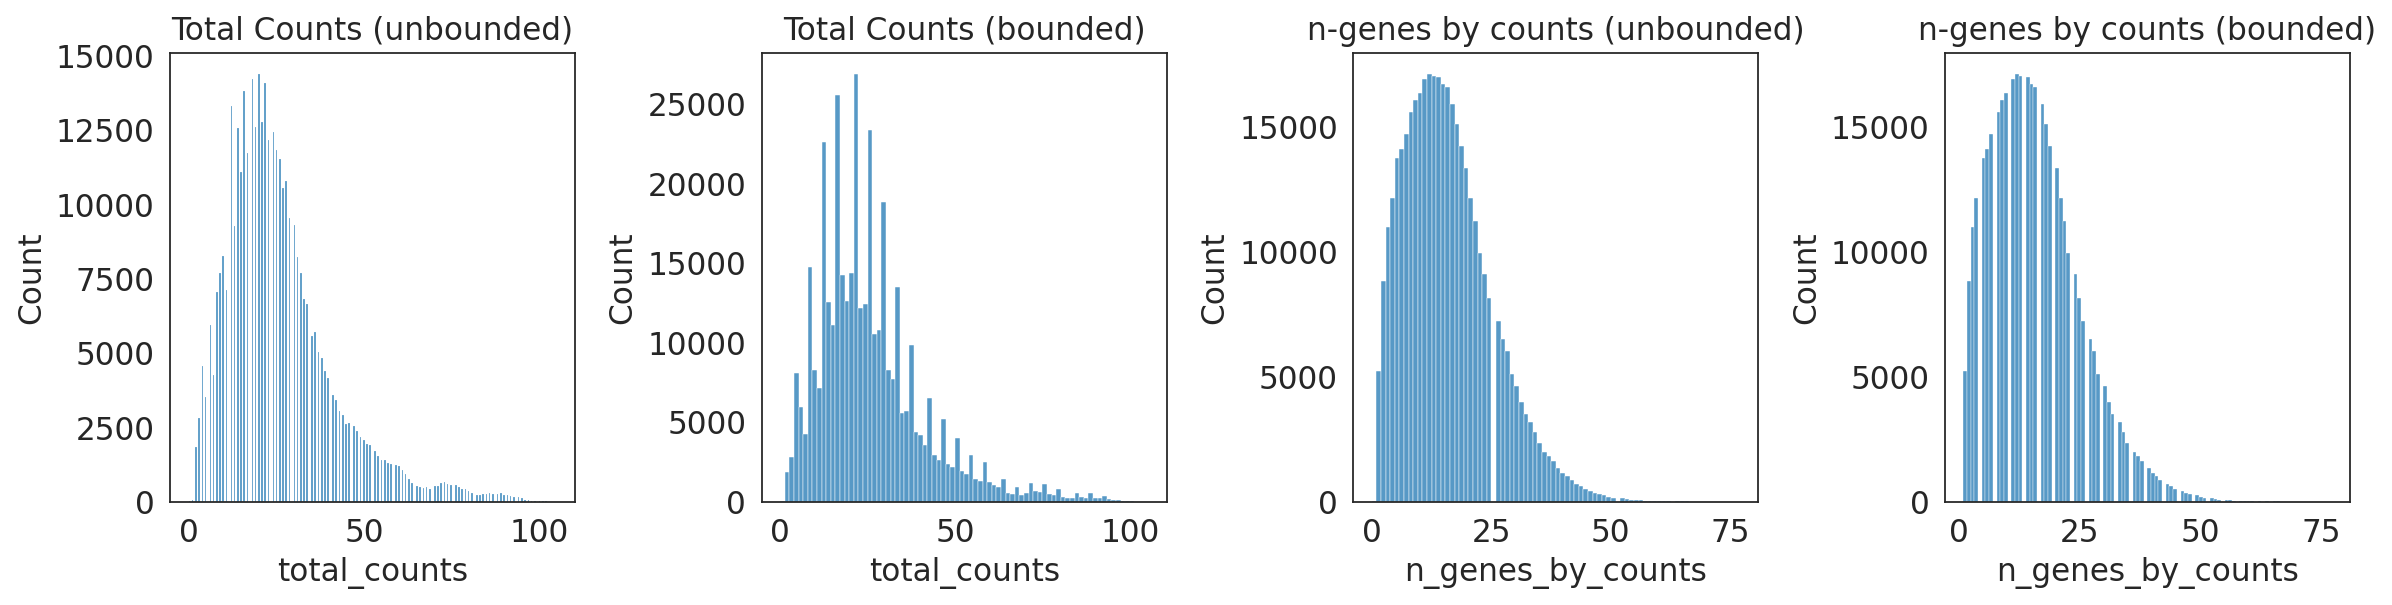

In [ ]:
from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions

# bin options for fomratting histograms
# Here, we set 'auto' for 1st figure, 80 bins for 2nd figure. and so on
hist_bin_options = ['auto', 80, 80, 100]

plot_qc_hist(adata, 
         total_counts_cutoff = 300, # for visualization
         n_genes_high_cutoff = 1000, # for visualization
         n_genes_low_cutoff = 0, # for visualization
         bin_options = hist_bin_options)

## Do an initial filter of cells by their cell counts, MT count and gene counts
### We can then first filter cells by their counts, MT and gene filters.
**NOTE:** I have decided not to filter on the basis of gene counts as 

In [ ]:
#from banksy_utils.filter_utils import filter_cells

# Filter cells with each respective filters
# adata = filter_cells(adata, 
#              min_count=10, 
#              max_count=1000, 
#              MT_filter=20, 
#              gene_filter=10)

### Plot the Histograms of the filtered dataset

In [ ]:
# hist_bin_options = ['auto', 100, 60, 100]

# plot_qc_hist(adata,
#         total_counts_cutoff=2000,
#         n_genes_high_cutoff=2000, 
#         n_genes_low_cutoff= 0,
#         bin_options = hist_bin_options)

### Visualize the position of cells using a scatter plot


{'fig_size': (6, 6), 's': 0.2, 'c1': 'red', 'c2': 'slateblue', 'label1': 'Original cells', 'label2': 'Remaining cells', 'add_circle': False, 'puck_center': (3330, 3180), 'puck_radius': 2550}


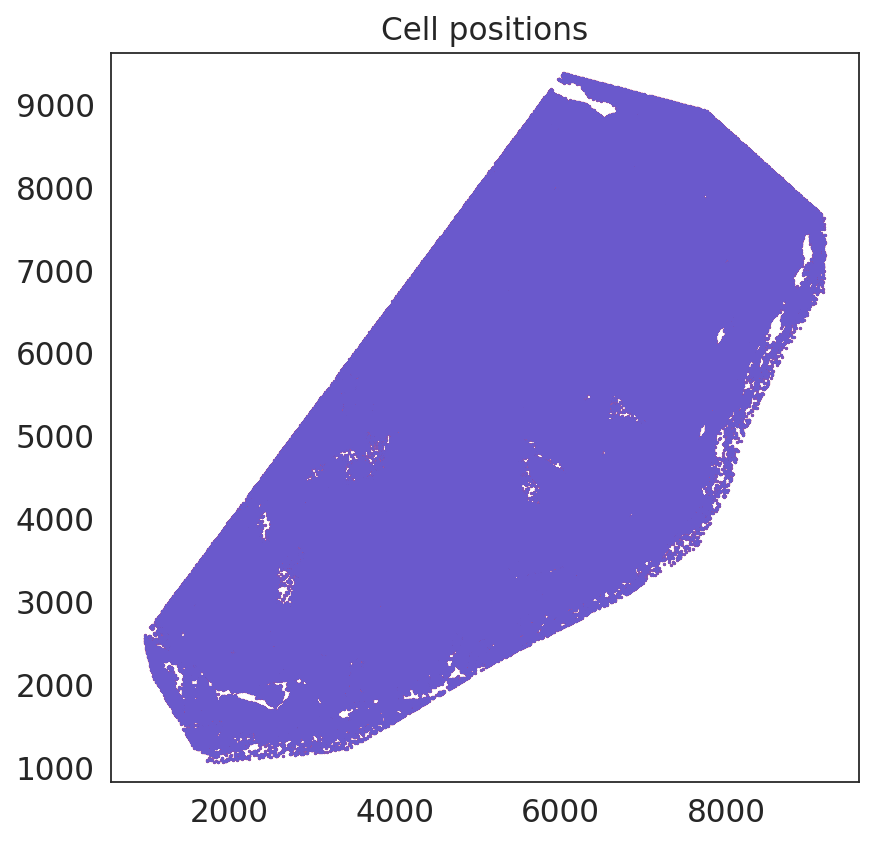

In [ ]:
# Visualize cell positions in puck
plot_cell_positions(adata,
            raw_x,
            raw_y,
            coord_keys=coord_keys,
            fig_size = (6,6))

## Normalize & Filter highly variable genes (HVG)

Normalize data matrix using `normalize_total`.


In [ ]:
from banksy_utils.filter_utils import normalize_total, filter_hvg, print_max_min

# Normalizes the anndata dataset
adata = normalize_total(adata)

--- Max-Min before normalization -----
Displaying max and min of Dataset
Max: 38.0, Min: 0.0

--- Max-Min after normalization -----
Displaying max and min of Dataset
Max: 23.000000000000004, Min: 0.0



### Filter by Highly Variable Genes (HVG) using a specified threshold

We use the **raw count data** (flavor = `"seurat_v3"`) or **log-transformed data** (flavor = `"seurat"`). Here, we recommend using the default `seurat` flavor from `Scanpy`.

Here we keep the original AnnData object (`adata_allgenes`) for the analysis of the results produced by BANKSY if nessecary. However, we will mostly be running banksy with the filtered AnnData object (`adata`)

**NOTE:** Banksy author Vipul Singhal did state at a Sydney Precision Data Science Centre talk (12/5/2025) that HVG is not recommended for Xenium data given how few genes there are in these analyses.

In [ ]:
# adata, adata_allgenes = filter_hvg(adata,
#             n_top_genes = 2000,
#             flavor="seurat")

## Generate spatial weights graph

#### In BANKSY, we imagine edges / connections in the graph to represent neighbour relationships between cells

In doing so, the banksy algorithm requires the following specifications in the main BANKSY algorithm:

1. The number of spatial neighbours `num_neighbours`, this is also known as the $k_{geom}$ parameter in the manuscript.
    
2. Assigning weights (dependent on inter-cell spatial distances) to edges in the connected spatial graph. By default, we use the `gaussian decay` option, where weights decay as a function of distnace to the index cell with $\sigma$ = `sigma`. As default, we set $\sigma$ to be the median distance between cells, and do not prescribe any cutoff-radius `p_outside` (no cutoff is conducted).

3. The Azumithal Gabor Filter parameter `max_m` which indicates whether to use the AGF (`max_m = 1`) or just the mean expression (`max_m = 0`). By default, we set `max_m = 1`.
    
    
### Construction of the spatial $k_{geom}$ Nearest-Neighbour graph

We represent connections between cells and its neighbours in a graph $G = \{N,E,W\}$, comprising of a set of nodes $n \in N$. edges representing connectivity between cells $e \in E$, the edges are be weighted $w \in W$ as a function of the spatial distance between cells.
    
Weight of edges can be represented by uniform distance (i.e., a closer neighbour will have a higher weight), or using `reciprocal` ($\frac{1}{r})$. As mentioned above, BANKSY by default applies a gaussian envelope function to map the distance (between nodes) to the `weights` the connection of cell-to-neighbor

In [ ]:
from banksy.main import median_dist_to_nearest_neighbour

# set params
# ==========
plot_graph_weights = True
k_geom = 15 # only for fixed type
max_m = 1 # azumithal transform up to kth order
nbr_weight_decay = "scaled_gaussian" # can also be "reciprocal", "uniform" or "ranked"

# Find median distance to closest neighbours, the median distance will be `sigma`
nbrs = median_dist_to_nearest_neighbour(adata, key = coord_keys[2])


Median distance to closest cell = 6.656677993468561

---- Ran median_dist_to_nearest_neighbour in 1.66 s ----



### Generate spatial weights from distance

Here, we generate the spatial weights using the gaussian decay function from the median distance to the k-th nearest neighbours as specified earlier.

The utility functions `plot_edge_histograms`, `plot_weights`, `plot_theta_graph` can be used to visualize the characteristics of the edges, weights and theta (from the AGF) respectively.

### Optional Visualization of Weights and edge graphs

(1) **Visualize the edge histogram** to show the histogram of distances between cells and the weights between cells by setting `plt_edge_hist = True`

(2) **Visualize weights** by plotting the connections. Line thickness is proportional to edge weight (normalized by highest weight across all edges) by setting `plt_weights = True`

(3) **Visualize weights with Azimuthal angles**. Visualizing the azimuthal angles computed by the AGF by colour, the azimuthal connectivities are annotated in red. Warning: this plot many take a few minutes to compute for large datasets. By default, `plt_agf_angles = False`

(4) **Visualize angles around random cell**. Plot points around a random index cell, annotated with angles from the index cell. `plot_theta = True`


Median distance to closest cell = 6.656677993468561

---- Ran median_dist_to_nearest_neighbour in 1.68 s ----

---- Ran generate_spatial_distance_graph in 3.53 s ----

---- Ran row_normalize in 1.28 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 14.25 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 14.234312281381337, mode = 15.235653141603937

---- Ran plot_edge_histogram in 0.24 s ----


Edge weights (weights between cells): median = 0.05895876725256419, mode = 0.032451149354905076

---- Ran plot_edge_histogram in 0.24 s ----

---- Ran generate_spatial_distance_graph in 5.55 s ----

---- Ran theta_from_spatial_graph in 2.98 s ----

---- Ran row_normalize in 1.29 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 19.48 s ----

----- Plotting Edge Histograms for m = 1 -----

Edge weights (distances between cells): median = 19.811137787352312, mode = 21.300317790874217

---- Ran plot_edge_histogram in 0.29 s ----




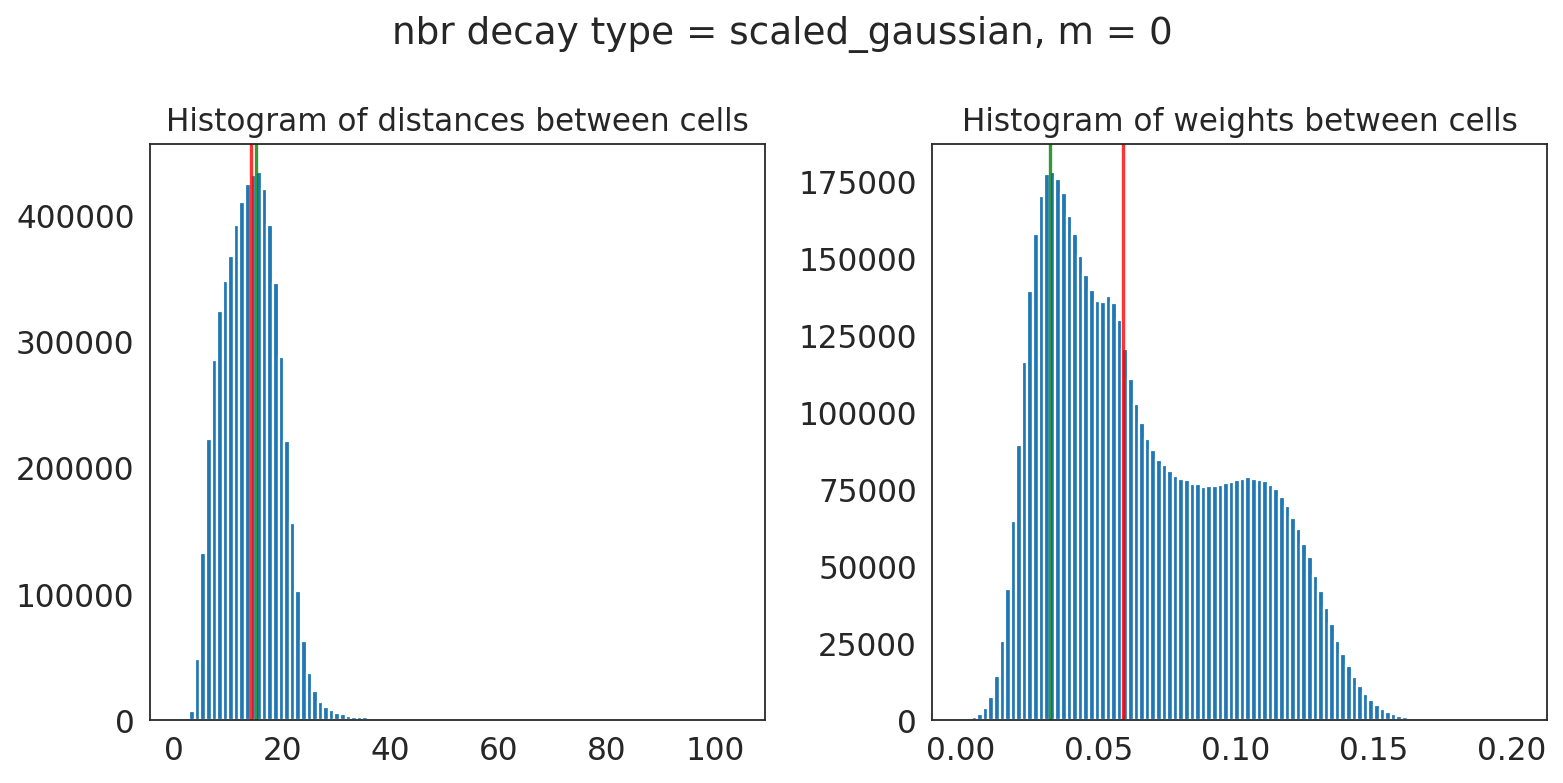

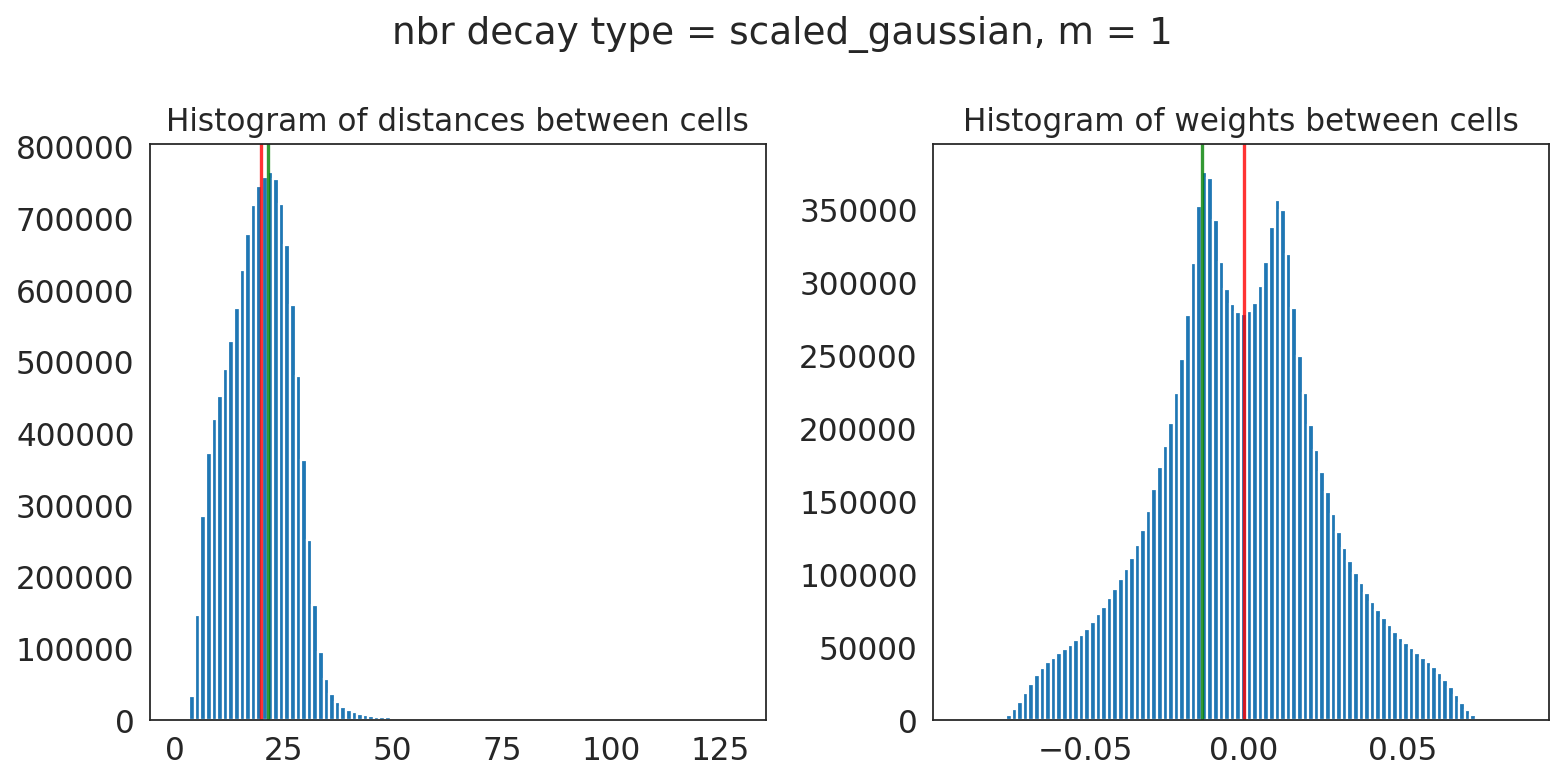

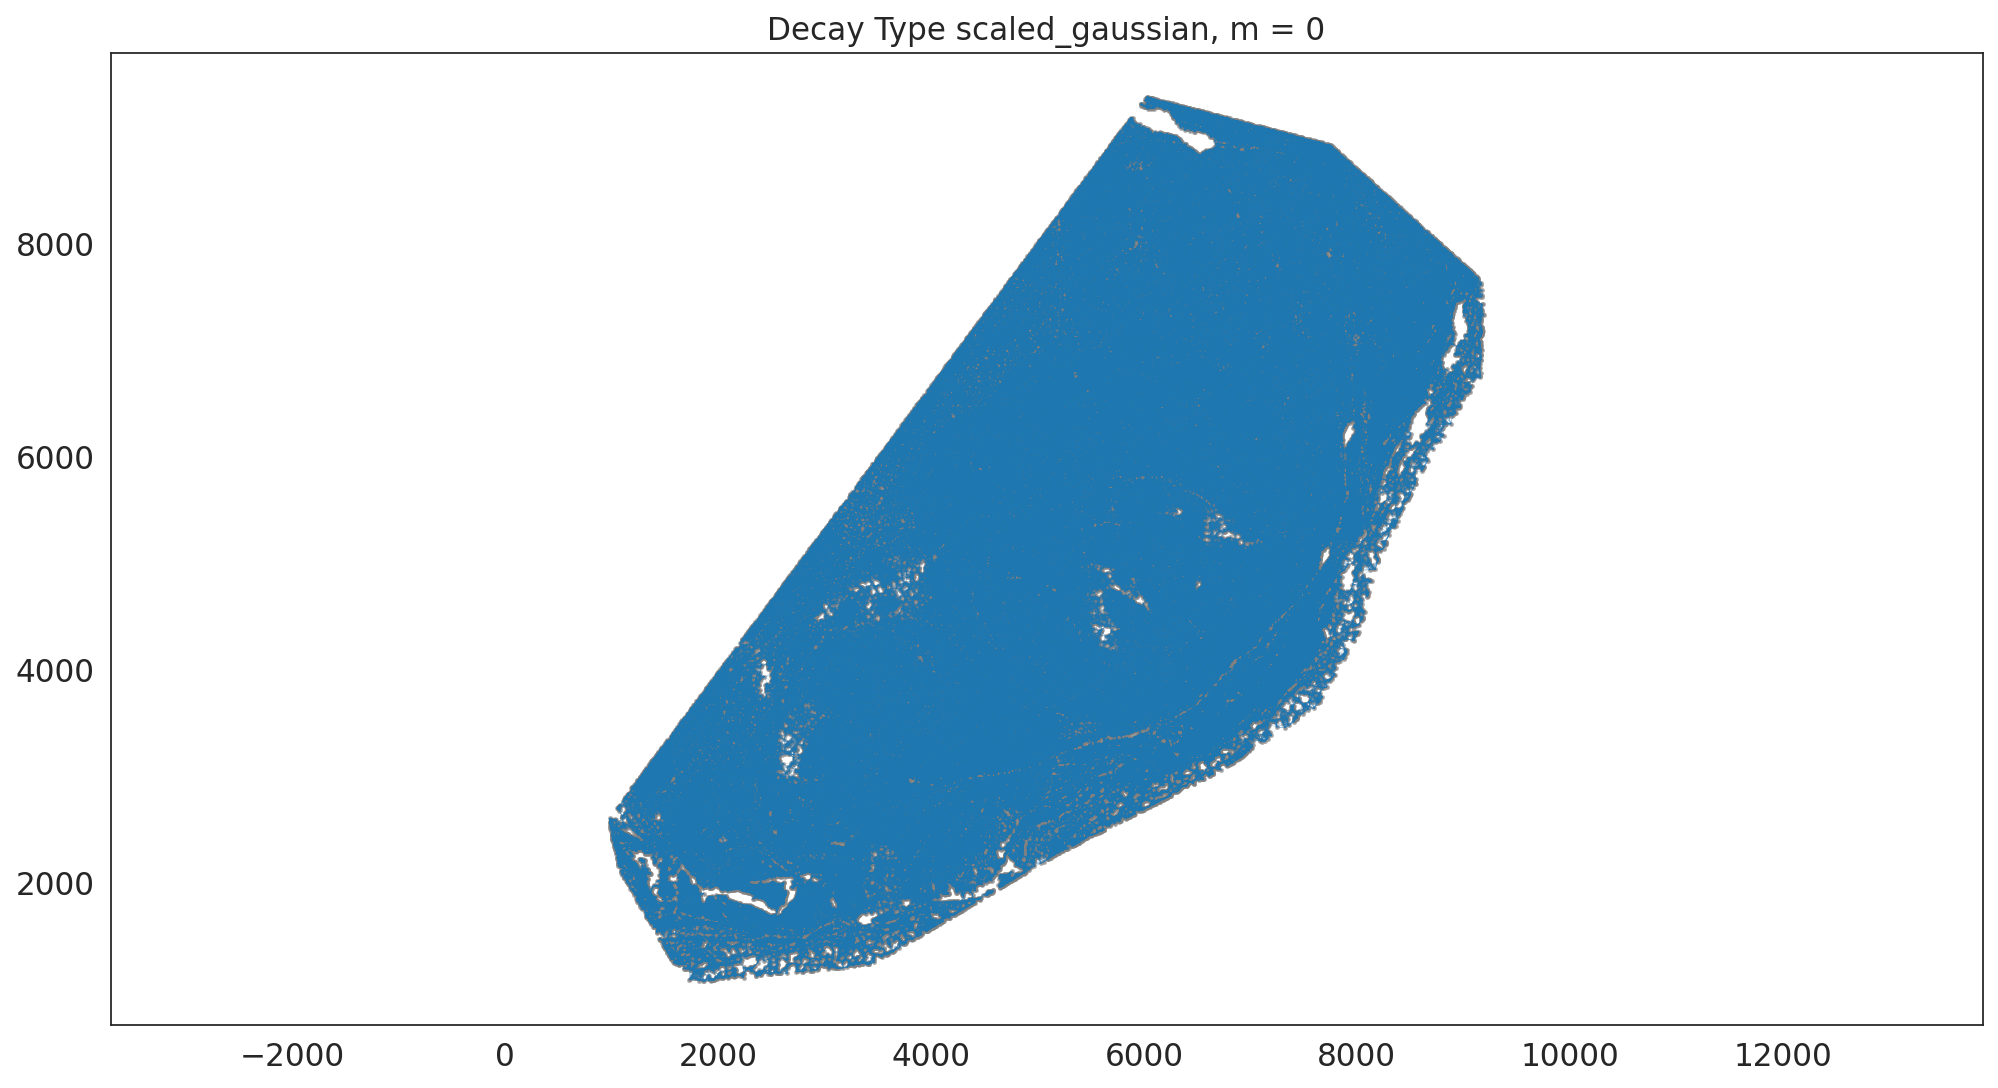

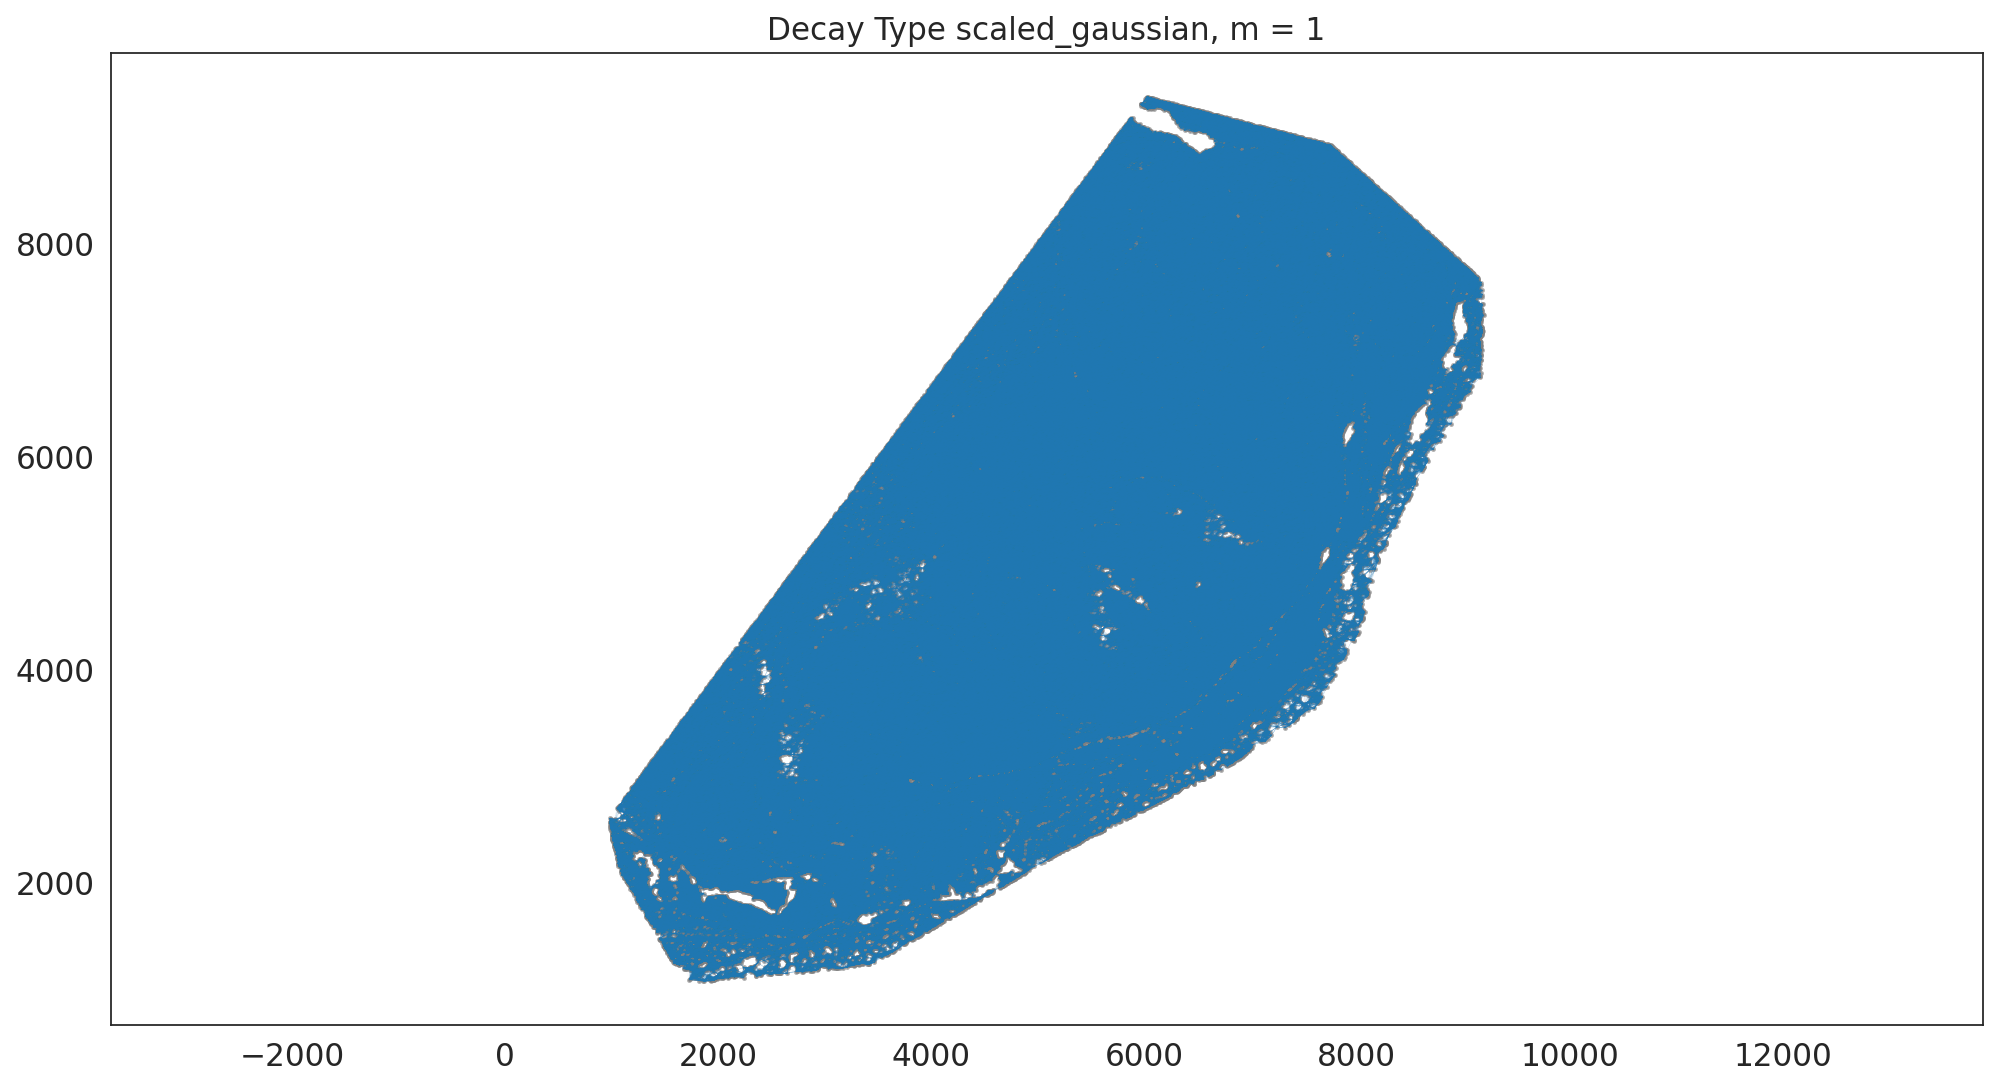

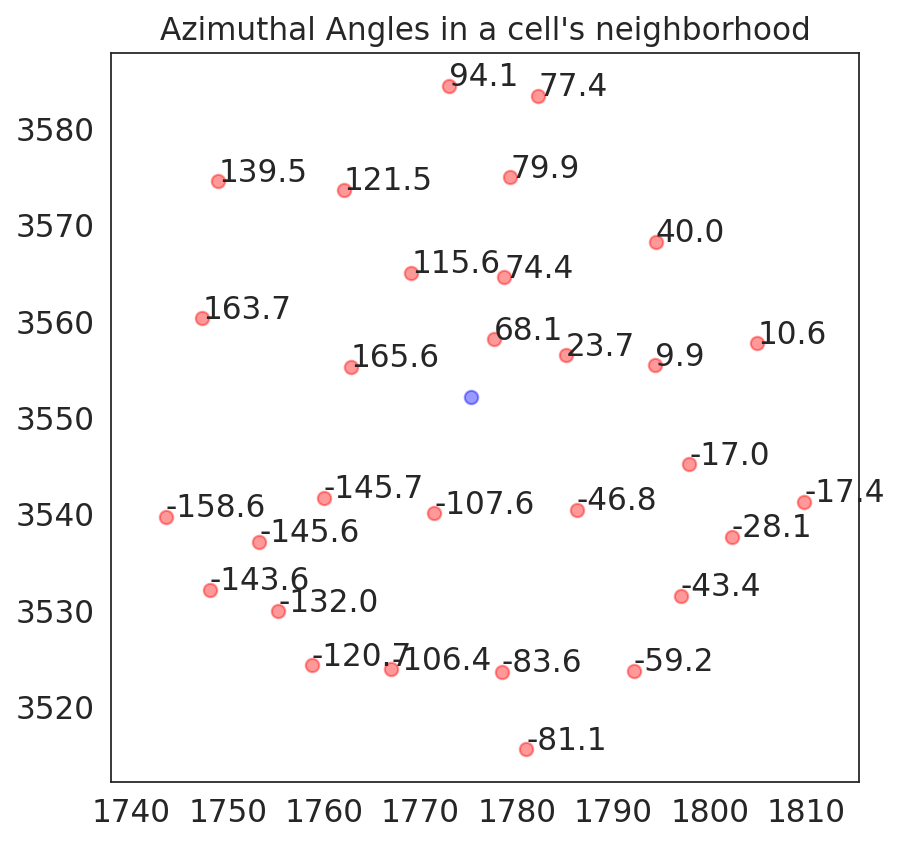

In [ ]:
from banksy.initialize_banksy import initialize_banksy

banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=True,
    plt_nbr_weights=True,
    plt_agf_angles=False, # takes long time to plot
    plt_theta=True,
)

## Generate BANKSY matrix

To generate the BANKSY matrix, we proceed with the following:

1. Matrix multiply sparse CSR weights matrix with cell-gene matrix to get **neighbour matrix** and the **AGF matrix** if `max_m` > 1
2. Z-score both matrices along **genes**
3. Multiply each matrix by a weighting factor $\lambda$ (We refer to this parameter as `lambda` in our manuscript and code)
4. Concatenate the matrices along the genes dimension in the form -> `horizontal_concat(cell_mat, nbr_mat, agf_mat)`

Here, we save all the results in the dictionary (`banksy_dict`), which contains the results from the subsequent operations for BANKSY. 

In [ ]:
## Parameter labels for f-string labelling
res_label = "0.30"
lambda_label = "0.50" #set to one of the lambda values for now, this can be switched

In [ ]:
from banksy.embed_banksy import generate_banksy_matrix

# The following are the main hyperparameters for BANKSY
resolutions = [0.3] # clustering resolution for UMAP
lambda_list = [0.5] # list of lambda parameters

banksy_dict, banksy_matrix = generate_banksy_matrix(adata, banksy_dict, lambda_list, max_m)

Runtime Aug-29-2025-15-23

304 genes to be analysed:
Gene List:
Index(['ACER1', 'ACTA2', 'ADAM12', 'AHNAK2', 'AIF1', 'AKR1C1', 'ALOX5AP',
       'APCDD1', 'APOD', 'AQP1',
       ...
       'TYR', 'TYROBP', 'TYRP1', 'UBE2C', 'VCAM1', 'VEGFA', 'VIM', 'VWF',
       'WDFY4', 'ZNF667-AS1'],
      dtype='object', length=304)

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <397292x397292 sparse matrix of type '<class 'numpy.float64'>'
	with 5959380 stored elements in Compressed Sparse Row format>, 1: <397292x397292 sparse matrix of type '<class 'numpy.complex128'>'
	with 11918760 stored elements in Compressed Sparse Row format>}}

Nbr matrix | Mean: 0.08 | Std: 0.25
Size of Nbr | Shape: (397292, 304)
Top 3 entries of Nbr Mat:

[[0.         0.05883863 0.        ]
 [0.         0.         0.08978879]
 [0.         0.         0.        ]]

AGF matrix | Mean: 0.04 | Std: 0.09
Size of AGF mat (m = 1) | Shape: (397292, 304)
Top entries of 

In [ ]:
#matrix_nbr = banksy_matrix.var
#print(matrix_nbr)
#matrix_nbr.to_csv(f"data/xenium/processed/{dataset_name}_banksy_matrix.csv")


In [ ]:
banksy_dict

{'scaled_gaussian': {'weights': {0: <397292x397292 sparse matrix of type '<class 'numpy.float64'>'
   	with 5959380 stored elements in Compressed Sparse Row format>,
   1: <397292x397292 sparse matrix of type '<class 'numpy.complex128'>'
   	with 11918760 stored elements in Compressed Sparse Row format>},
  'norm_counts_concatenated': <397292x912 sparse matrix of type '<class 'numpy.float64'>'
  	with 94387417 stored elements in COOrdinate format>,
  0.5: {'adata': AnnData object with n_obs × n_vars = 397292 × 912
       obs: 'nucleus_area', 'nCount_Xenium', 'nFeature_Xenium', 'segmentation_method', 'nCount_BlankCodeword', 'nFeature_BlankCodeword', 'nCount_ControlCodeword', 'nFeature_ControlCodeword', 'nCount_ControlProbe', 'nFeature_ControlProbe', 'x', 'y', 'cell_area', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt'

In [ ]:
# dict_matrix=banksy_dict["scaled_gaussian"][0.2]['adata'].obs.keys()
# print(dict_matrix)

# #dict_matrix.to_csv(f"data/xenium/processed/{dataset_name}_dict_matrix.csv")


KeyError: 0.2

### Append Non-spatial results to the `banksy_dict` for comparsion

In [ ]:
from banksy.main import concatenate_all

banksy_dict["nonspatial"] = {
    # Here we simply append the nonspatial matrix (adata.X) to obtain the nonspatial clustering results
    0.0: {"adata": concatenate_all([adata.X], 0, adata=adata), }
}

print(banksy_dict['nonspatial'][0.0]['adata'])

## Determine number of PCs to input into UMAP
The function helps to determine the number of principal components to use for UMAP


In [ ]:
# #adata.X.shape
# #adata.layers.keys()
# #adata.obs.keys()
# #print(adata.obs_names)
# #print(adata.obs.index)
# #print(adata.X[:5, :5]) 

# #adata.var_names # feature names
# #adata.obs_names # cell ids

# from banksy_utils.pca import plot_singular_values
# import numpy as np

# # X is a matrix of cells vs gene names
# # Store the cells vs genes (features) as a matrix for PCA
# X = adata.X.toarray()

# # Transpose the matirx so that the columns are the genes (features) not the cell IDs
# X = X.T
# X.shape

# # Calculate the higher singular value 
# from banksy_utils.pca import noise_equiv_singular_value

# noise_sv, all_permuted_svs = noise_equiv_singular_value(
#     data = X,
#     num_permutations = 100,
#     #average_type = "mean",
#     verbose = True
#     )
# print(f"Noise threshold (mean top singular value of permuted data): {noise_sv:.4f}")

In [ ]:
# ## Perform PCA 
# from sklearn.decomposition import PCA

# pca = PCA(n_components=100).fit(X)


# ## Plot singular values vs noise to determine the optimal number of PC above the noise threshold
# from banksy_utils.pca import plot_singular_values

# plot_singular_values(pca, noise_highest_sv=noise_sv, title="Singular values vs noise",figsize=(40,10))


In [ ]:
# from banksy_utils.pca import plot_remaining_variance
# plot_remaining_variance(pca, figsize=(15,15))

## Reduce dimensions of each data matrix
We utilize two common methods for dimensionality reduction:

1. PCA (using `scikit-learn`), we reduce the size of the matrix from $3*N_{genes}$ to `pca_dims`. As a default settings, we reduce to 20 dimensions.
2. UMAP (`UMAP` package), which we use to visualize expressions of clusters in the umap space (2-D space).

In [ ]:
from banksy_utils.umap_pca import pca_umap

pca_dims = [20] # Dimensionality in which PCA reduces to

pca_umap(banksy_dict,
         pca_dims = pca_dims,
         add_umap = True,
         #plt_remaining_var = True,
         )

#pca label for downstream f-string labels
pca_label = "20"

### Cluster cells using a partition algorithm

For the purpose of this dataset, we cluster cells using the `leiden` algorithm (use `!pip install leidenalg` if package missing) partition methods. Other clustering algorithms include `louvain` (another resolution based clustering algorithm), or `mclust` (a clustering based on gaussian mixture model). 

Note that by default, we recommend resolution-based clustering (i.e., `leiden` or `louvain`) if no prior information on the number of clusters known. However, if the number of clusters is known *a priori*, the user can use `mclust` (gaussian-mixture model) by specifying the number of clusters beforehand.

In [ ]:
#from banksy.cluster_methods import run_Leiden_partition
from banksy.cluster_methods import run_Leiden_partition_parallel

# results_df, max_num_labels = run_Leiden_partition(
#     banksy_dict,
#     resolutions,
#     num_nn = 50,
#     num_iterations = -1,
#     partition_seed = seed,
#     match_labels = True,
# )

# Parallelisation test
results_df, max_num_labels = run_Leiden_partition_parallel(
    banksy_dict,
    resolutions,
    num_nn=50,
    max_workers=7
)

In [ ]:
max_num_labels

## Plot results

### Visualize the clustering results from BANKSY, including the clusters from the Umap embbedings

In [ ]:
from banksy.plot_banksy import plot_results

c_map =  'tab20' # specify color map
weights_graph =  banksy_dict[f"{nbr_weight_decay}"]['weights'][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels = False,
    coord_keys = coord_keys,
    max_num_labels  =  max_num_labels, 
    save_path = os.path.join(file_path, 'tmp_png'),
    save_fig = True, # save the spatial map of all clusters
    save_seperate_fig = True, # save the figure of all clusters plotted seperately
    dataset_name = f"{dataset_name}",
    save_fullfig=True
)

### Cell type annotation - lambda = 0.2

In [ ]:
from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata,  refine_cell_types

# # Here we manually assign clusters to their identity using a dictionary
# cluster2annotation_spatial = {
#     "0" : "Granular Layer",
#     "2" : "Purkinje/Bergmann",
#     "3" : "Molecular layer interneurons",
#     "4" : "Oligodendrocyte/Polydendrocyte",
#     "5" : "RBC",
# }

# pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

# Here we manually assign clusters to their identity using a dictionary
cluster2annotation_spatial = {
    "0" : "0",
    "1" : "1",
    "2" : "2",
    "3" : "3",
    "4" : "4",
    "5" : "5",
    "6" : "6",
    "7" : "7",
    "8" : "8",
    "9" : "9",
    "11" : "10",
    "12" : "12",
    "13" : "13",
    "14" : "14",
    "15" : "15",
    "16" : "16",
    "17" : "17",
    "18" : "18",
    "19" : "19",
    "20" : "20"
}

pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

cluster2annotation_nonspatial = {
    "0" : "0",
    "1" : "1",
    "2" : "2",
    "3" : "3",
    "4" : "4",
    "5" : "5",
    "6" : "6",
    "7" : "7",
    "8" : "8",
    "9" : "9",
    "10" : "10",
    "11" : "11",
    "12" : "12",
    "13" : "13",
    "14" : "14",
    "15" : "15",
    "16" : "16",
    "17" : "17",
    "18" : "18",
    "19" : "19",
    "20" : "20",
    "21" : "21",
    "22" : "22",
    "23" : "23",
    "24" : "24",
    "25" : "25",
    "26" : "26",
    "27" : "27",
    "28" : "28",
    "29" : "29",
    "30" : "30",
    "31" : "31",
    "32" : "32",
    "33" : "33",
    "34" : "34",
    "35" : "35",
    "36" : "36",
    "37" : "37",
    "38" : "38",
    "39" : "39",
    "40" : "40",
    "41" : "41",
    "42" : "42",
    "43" : "43",
    "44" : "44",
    "45" : "45",
    "46" : "46",
    "47" : "47",
    "48" : "48",
    "49" : "49",
    "50" : "50",
    "51" : "51",
    "52" : "52",
    "53" : "53",
}

In [ ]:
#Here, most clusters match so copy labels from spatial
#cluster2annotation_nonspatial = cluster2annotation_spatial.copy()

# # cluster2annotation_nonspatial["4"] = "Purkinje/Bergmann"
# # cluster2annotation_nonspatial["8"] = "other"
# # cluster2annotation_nonspatial["11"] = "Choroid Plexus"
# # cluster2annotation_nonspatial["15"] = "other"

# cluster2annotation_nonspatial = {
#     "2" : "2",
#     "4" : "4"
# }

print(cluster2annotation_spatial,"\n", cluster2annotation_nonspatial)

# save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
                                    pca_dims,
                                    lambda_list, 
                                    resolutions,
                                    cluster2annotation_spatial,
                                    cluster2annotation_nonspatial)

In [ ]:
#print(adata_spatial.__repr__())
#print(lambda_list)
#print(results_df)
#banksy_dict["scaled_gaussian"][0.50]['adata']
#adata_spatial.obs[f"labels_scaled_gaussian_pc{pca_label}_nc{lambda_label}_r{res_label}"]
adata_spatial.obs

In [ ]:
#banksy_dict["scaled_gaussian"][0.2]['adata']
#adata_spatial.obs["labels_scaled_gaussian_pc20_nc0.20_r0.50"]
#pca_label
#lambda_label
res_label


In [ ]:
## Store the cluster labels as a string in .obs
banksy_dict[f"{nbr_weight_decay}"][0.2]['adata'] #lambda = 0.20
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"]= adata_spatial.obs[f"labels_scaled_gaussian_pc{pca_label}_nc{lambda_label}_r{res_label}"].astype(str)

In [ ]:
## Pull out genes as data frame
genes = adata.var_names
gene_df = pd.DataFrame(adata.X.toarray(), columns=genes, index=adata.obs_names)
#print(gene_df)

gene_count_across_cells = gene_df.sum(axis=0)
gene_count_across_cells.to_frame()
gene_count_across_cells.columns = ["gene", "counts"]

print(gene_count_across_cells)
gene_count_across_cells.to_csv(f"data/xenium/processed/{dataset_name}_gene_count_across_cells_not_SCTransformed.csv")
type(gene_count_across_cells)

In [ ]:
print(adata_spatial.__repr__())

# Top expressed genes per cluster

### Spatial clustering results

In [ ]:
import scanpy as sc

# Rank genes and identify cluster gene markers
sc.tl.rank_genes_groups(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
    method='wilcoxon',
    key_added=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"
)


In [ ]:
adata_spatial.uns['banksy_cluster_pc20_nc0.20_r0.50_markers']

In [ ]:
## Check which cluster keys exist

#adata_spatial.uns['banksy_cluster_pc20_nc0.20_r0.50_markers']['names']
adata_spatial.uns['banksy_cluster_pc20_nc0.20_r0.50_markers']['names'].dtype

In [ ]:
adata_spatial.uns['banksy_cluster_pc20_nc0.20_r0.50_markers']['names']['1'][:20]

In [ ]:
import copy

def filter_ranked_genes_by_type(adata, key, gene_type='raw', top_n=20, new_key_suffix="_raw_only"):
    """
    This function filters the ranked gene results (after running sc.tl.rank_genes_groups()) to include
    only genes of specific annotation and saves the results under a new key in 
    adata_spatial.uns, where:
    raw = markers without suffixes "_nbr_0" and "_nbr_1", which are used to determine cluster identity
    _nbr_0 = mean neighbour expression, these are genes that are expressed in cell neighbours
    _nbr_1 = Azimuthal Gabor filter output, these genes expressed at a boundary of spatial interface in a directional pattern
    """

    # Copy the full rank_genes_groups results
    original= adata.uns[key]
    filtered= copy.deepcopy(original) 

    # Get cluster names
    clusters = original['names'].dtype.names

    # Create new structured arrays for all the .uns data
    new_names = np.recarray(shape=(top_n,), dtype = [(c, object) for c in clusters])
    new_scores = np.recarray(shape=(top_n,), dtype = [(c, float) for c in clusters])

    for c in clusters:
        # Get the full list of genes and scores
        genes = original['names'][c]
        scores = original['scores'][c]

        # Filter the genes based on their gene_type annotation i.e., 'raw' for no suffix
        if gene_type == 'raw':
            mask=[not(g.endswith("_nbr_0") or g.endswith("_nbr_1")) for g in genes]
        elif gene_type == "nbr_0":
            mask=[g.endswith("_nbr_0") for g in genes]
        elif gene_type == "nbr_1":
            mask=[g.endswith("_nbr_1") for g in genes]
        else:
            raise ValueError("Invalid gene_type. Use 'raw', 'nbr_0' or 'nbr_1'.")

        # Apply the filters and store the top_n genes and scores
        # initialise empty lists
        filtered_genes = []
        filtered_scores = []

        # Iterate through each gene and its corresponding mask value
        for g, m, score in zip(genes, mask, scores):
            if m:
                filtered_genes.append(g)
                filtered_scores.append(score)
    
        # Keep only the top N genes and scores
        filtered_genes = filtered_genes[:top_n]
        filtered_scores = filtered_scores[:top_n]

        # pad the top genes if necessary
        filtered_genes += [''] * (top_n - len(filtered_genes))
        filtered_scores += [np.nan] * (top_n - len(filtered_scores))

        # Assign to the structured arrays
        new_names[c] = filtered_genes
        new_scores[c] = filtered_scores

    # store the filtered results under a new key

    new_key = key + new_key_suffix
    filtered['names'] = new_names
    filtered['scores'] = new_scores
    adata.uns[new_key] = filtered

    # # Copy group labels to .obs for downstream plotting e.g., sc.pl.rank_genes_groups_heatmap(
    # original_groupby = key.replace("_markers", "")
    # new_groupby = original_groupby + new_key

    # if original_groupby in adata.obs.columns:
    #     adata.obs[new_groupby] = adata.obs[original_groupby].copy()
    #     print(f"Copied cluster labels to adata.obs['{new_groupby}']")
    # else:
    #      print(f"⚠️ Could not find original groupby column '{original_groupby}' in adata.obs.")

    # print(f"Stored filtered {gene_type} markers in adata.uns['{new_key}']")
    return new_key




In [ ]:
key_filtered = filter_ranked_genes_by_type(
    adata_spatial,
    key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers",
    gene_type = "raw",
    new_key_suffix="_raw",
    
    #gene_type = "nbr_0",
    #new_key_suffix="_nbr_0",
    
    #gene_type = "nbr_1",
    #new_key_suffix="_nbr_1",
    top_n= 20 
)

In [ ]:
# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_spatial, 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers", 
    key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_0", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_1", 
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_nbr_0.png")

In [ ]:
sc.pl.violin(adata_spatial, "total_counts", groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}")

In [ ]:
sc.tl.dendrogram(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
)

sc.pl.rank_genes_groups_heatmap(
    adata_spatial, 
    key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers", 
    n_genes=5,
    cmap = "plasma",
    vmin=0,
    vmax=2,
    show_gene_labels = True,
    save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
)

### Non-spatial clustering results

In [ ]:
# banksy_dict['scaled_gaussian'][0.2]['adata'] #lambda = 0.2
adata_nonspatial.obs['banksy_cluster_nonspatial']= adata_nonspatial.obs[f"labels_nonspatial_pc{pca_label}_nc0.00_r{res_label}"].astype(str)

In [ ]:
# ## Rank the genes for the non-spatial data

# sc.tl.rank_genes_groups(
#     adata_nonspatial,
#     groupby='banksy_cluster_nonspatial',
#     method='wilcoxon',
#     key_added='banksy_markers_nonspatial'
# )

In [ ]:
# ## Plot the top 20 marker genes per cluster

# sc.pl.rank_genes_groups(
#     adata_nonspatial, 
#     key='banksy_markers_nonspatial', 
#     n_genes=20, 
#     fontsize=15,
#     save= f"_{dataset_name}_pc{pca_label}_r{res_label}_top_gene.png")

In [ ]:
# sc.tl.dendrogram(
#     adata_spatial,
#     groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
# )

# sc.pl.rank_genes_groups_heatmap(
#     adata_nonspatial, 
#     key='banksy_markers_nonspatial', 
#     n_genes=5,
#     cmap = "plasma",
#     #vmin=0,
#     #vmax=2,
#     show_gene_labels = True,
#     save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
    


### Export the top 20 clusters to .csv

In [ ]:
# Extract cluster genes
#cluster_genes = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"] #all gene annotations included
cluster_genes = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw"] # raw genes only
#cluster_genes = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_0"] # nbr_0 genes only

# Extract cluster labels
clusters = cluster_genes['names'].dtype.names

# Create cluster gene data frame
top_genes = pd.DataFrame({
    cluster_group: cluster_genes['names'][cluster_group][:21]
    for cluster_group in clusters
 })

print(top_genes)

# Write to .csv
top_genes.to_csv(f"data/xenium/processed/{dataset_name}_cluster_top_genes_raw.csv")
#top_genes.to_csv(f"data/xenium/processed/{dataset_name}_cluster_top_genes_nbr_0.csv")

In [ ]:
## Extract cluster ids with scores for manual annotation
cluster_ids = cluster_genes['names'].dtype.names
#marker_data = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"]
marker_data = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw"]
#marker_data = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_0"]

# vector to store data for all clusters
all_cluster_genes = []

for cluster in cluster_ids:
    genes = marker_data['names'][cluster][:21]
    scores = marker_data['scores'][cluster][:21]

## Create a data frame of the genes and their z-scores
    cluster_df = pd.DataFrame({
        "cluster": int(cluster),
        "gene": genes, 
        "score": scores
        })

    all_cluster_genes.append(cluster_df)

# # Combine into one long data frame

all_cluster_genes_df = pd.concat(all_cluster_genes, ignore_index=True)
#all_cluster_genes_df = all_cluster_genes_df.sort_values(by= 'score', ascending = False)
all_cluster_genes_df.head(40)

# Write to .csv
all_cluster_genes_df.to_csv(f"data/xenium/processed/cluster_top_genes_with_scores_{dataset_name}_{res_label}_{lambda_label}_{pca_label}_raw.csv")
#all_cluster_genes_df.to_csv(f"data/xenium/processed/cluster_top_genes_with_scores_{dataset_name}_{res_label}_{lambda_label}_{pca_label}_nbr_0.csv")

## Relabel cluster with cell type annotation

In [ ]:
## The top 20 gene markers for each cluster are assessed for cell cluster annotation
 
# adata_spatial.obs['banksy_cluster_pc16_nc0.20_r0.50'].unique()

new_labels = {
     '0' : 'Melanoma Cells _0',
     '1' : 'Cancer ASsociated Fibroblasts_1',
     '2' : 'Melanoma Cells (IFN/Immune modulated_2',
     '3' : 'Melanoma Cells (EMT-like/Pro-invasive)_3',
     '4' : 'Exhausted Cytotoxic CD8+ T Cells (CTLA4+)_4',
     '5' : 'Naive T Cells (low_confidence)_5', 
     '6' : 'Proliferating Melanoma Cells_6',
     '7' : 'M2-like Tumour Associated Macrophages (CXCL16+)_7',
     '8' : 'Vascular Endothelial Cells (CXCL12+)_8',
     '9' : 'B Cells (CXCL12+)_9',
     '10' : 'Differentiated Keratinocytes_(low_confidence)_10',
     '11' : 'Inflammed Keratinocytes (low_confidence)_11',
     '12' : 'Proliferating Keratinocytes (low_confidence)_12',
     '13' : 'Plastic Melanoma Tumour_cells (low_confidence)_13',
     '14' : 'Melanoma Cells Transitional (low_confidence)_14',
     '15' : 'Basal Suprabasal Keratinocytes (low_confidence)_15',
     '16' : 'Basal Suprabasal_Keratinocytes_(low_confidence)_16',
     '17' : 'Melanoma_Cells_Interferon_Responsive (low_confidence)_17',
     '18' : 'Basal Keratinocytes (low_confidence)_18',
     '19' : 'Basal Suprabasal Keratinocytes (low_confidence)_19',
     '20' : 'M2-like Tumour Associated_Macrophages (low_confidence)_20'
    }

cluster_col = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs[cluster_col].map(new_labels)

#adata_spatial.obs.keys()
new_labels

In [ ]:
## Store the UMAP results in the .obsm slot
adata_spatial.obsm['X_umap'] = banksy_dict['scaled_gaussian'][0.2]['adata'].obsm[f"reduced_pc_{pca_label}_umap"]

## Visualisations

### Annotated UMAP

In [ ]:
# Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
]

with rc_context({"figure.figsize": (3,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=50, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}.png"
        )

### Gene expression Dotplot

In [ ]:
# Extract cluster genes
cluster_genes = adata_spatial.uns[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"]

# Extract cluster labels
clusters = cluster_genes['names'].dtype.names

# Create cluster gene data frame
plot_genes = pd.DataFrame({
    cluster_group: cluster_genes['names'][cluster_group][:10]
    for cluster_group in clusters
 })

## Create a dictionary for the top 20 marker genes for each cluster
cluster_dict = {f"cluster_{i}": list(plot_genes[str(i)]) for i in range(len(plot_genes.columns))}

marker_genes_dict = {
    # 'Dedifferentiated Melanoma Cells_0' : cluster_dict["cluster_0"],
    # 'Cancer Associated Fibroblasts_1' : cluster_dict["cluster_1"],
     'M2-like Tumour Associated Macrophages_2' : cluster_dict["cluster_2"],
    # 'Pigmented Melanoma Cells_3' : cluster_dict["cluster_3"],
    # 'CD8+ T Cells_4' : cluster_dict["cluster_4"],
    # 'M2 Macrophages_5' : cluster_dict["cluster_5"], #merge with cluster
    # 'Vascular Endothelial Cells_6' : cluster_dict["cluster_6"],
    # 'Cycling Melanoma Cells_7' : cluster_dict["cluster_7"]
}


In [ ]:
## Generate dot plot
sc.pl.dotplot(
    adata_spatial,
    marker_genes_dict,
    f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
    dendrogram=True,
    save=f"{dataset_name}_dot_plot.png"
    )

## Export the banksy dictionary, the adata objects and the results_df


In [ ]:
# Save AnnData objects with clustering results

adata_spatial.write_h5ad(
    filename = f"data/xenium/processed/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad",
    compression="gzip"
    )

adata_nonspatial.write_h5ad(
    filename = f"data/xenium/processed/{dataset_name}_clustered_nonspatial_pc{pca_label}_r{res_label}.h5ad"
)

In [ ]:
## Export the banksy_dict dictionary as a .pkl file
## Use gzip to save it with compression
import gzip
import pickle
# with gzip.open(f"data/xenium/processed/{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz", "wb") as f:
#     pickle.dump(banksy_dict, f)


## Export the results_df data frame as a .pkl file
with gzip.open(f"data/xenium/processed/results_df_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.pkl.gz", "wb") as f:
    pickle.dump(results_df, f)

In [ ]:
# ## Read in the anndata object, banksy_dict and results_df
# dataset_label = "CK_skin_res"
# pca_label = "20"
# lambda_label = "0.20"
# res_label = "0.50"
# adata_spatial = ad.read_h5ad(f"data/xenium/processed/{dataset_label}/{dataset_label}_roi_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad")

# ## Export dictionary

# ## save the banksy dict as a pickle file to load it in later and avoid having to initialize repeatedly to save time
# ## use gzip to save it with compression
# import gzip
# import pickle
# with gzip.open(f"data/xenium/processed/{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz", "rb") as f:
#     banksy_dict = pickle.load(f)


### (Data Analysis) Analyzing Results from BANKSY

We manually annotate the cluster layers generated by BANKSY and analyze its generated clusters. <br> However, note that the clusters may differ slightly between versions of different modules due to the randomness in the leiden partition. The annotations below are exclusive to the analysis obtained from our environnment only.

In [ ]:
# from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata,  refine_cell_types

# # Here we manually assign clusters to their identity using a dictionary
# cluster2annotation_spatial = {
#     "0" : "Granular Layer",
#     "2" : "Purkinje/Bergmann",
#     "3" : "Molecular layer interneurons",
#     "4" : "Oligodendrocyte/Polydendrocyte",
#     "5" : "RBC",
# }

# pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

In [ ]:
# # Here, most clusters match so copy labels from spatial
# # cluster2annotation_nonspatial = cluster2annotation_spatial.copy()
# # cluster2annotation_nonspatial["4"] = "Purkinje/Bergmann"
# # cluster2annotation_nonspatial["8"] = "other"
# # cluster2annotation_nonspatial["11"] = "Choroid Plexus"
# # cluster2annotation_nonspatial["15"] = "other"

# cluster2annotation_nonspatial = {
#     "0" : "Granular Layer",
#     "2" : "Purkinje/Bergmann",
#     "3" : "Molecular layer interneurons",
#     "4" : "Oligodendrocyte/Polydendrocyte",
#     "5" : "RBC",
# }

# print(cluster2annotation_spatial,"\n", cluster2annotation_nonspatial)

# # save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

# adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
#                                     pca_dims,
#                                     lambda_list, 
#                                     resolutions,
#                                     cluster2annotation_spatial,
#                                     cluster2annotation_nonspatial)

### DE analysis of self genes (only) from BANKSY clustering

combine 2 Granular layer clusters, merge all unknown clusters

In [ ]:
# from banksy_utils.plot_utils import plot_DE_genes, plot_DE_genes_refined, plot_connection_grid, plot_clusters

# cluster2annotation_refine = {
#     "RBC" : "other",
# }

# adata_spatial_filtered, adata_nonspatial_filtered = refine_cell_types(adata_spatial, 
#                                                                       adata_nonspatial,
#                                                                       cluster2annotation_refine
#                                                                       )

In [ ]:
adata_self = plot_DE_genes_refined(adata_spatial_filtered, plot_heatmap = False, save_fig = False)

### Show connection grid

Show heatmap representing how intermingled each cluster is with each other cluster. Arrange clusters (each corresponding to a cell type) in order of layers of the cerebellum, from MLI to Oligo.

In [ ]:
# cell_types = ["Molecular layer interneurons", 
#               "Purkinje/Bergmann", 
#               "Granular Layer",
#               "Oligodendrocyte/Polydendrocyte",]

# plot_connection_grid(
#     banksy_dict["scaled_gaussian"]["weights"][0].copy(),
#     adata_nonspatial,
#     adata_spatial,
#     cell_types= cell_types,
#     save_fig=False
# )

compare **spatial map** of selected clusters side by side:

In [ ]:
# # choose colours for each cluster
# colors_dict = {
#     "Granular Layer": "tab:blue",
#     "Molecular layer interneurons": "tab:orange",
#     "Purkinje/Bergmann": "tab:red",
#     "Oligodendrocyte/Polydendrocyte": "tab:green",
# }

# plot_clusters(
#     adata_spatial,
#     adata_nonspatial,
#     colors_dict,
# )

## Plot DE genes of clusters from scRNAseq reference atlas
Note this requires the RCTD weights from the dropviz.org webpage

In [ ]:
# # display(adata_allgenes)
# print_max_min(adata_allgenes)

# # z-score the unfiltered gene-cell matrix
# # ---------------------------------------
# sc.pp.scale(adata_allgenes)
# # display(adata_allgenes)
# print_max_min(adata_allgenes)

### Get scRNA-seq reference marker genes and compute metagene

Marker genes are obtained from reference scRNA-seq dataset available at **dropviz.org**. 

DE genes are compared against rest of cerebellum with parameters (*default*):
 - Minimum Fold Ratio = 2
 - Minimum P-Value Exponent = -100
 - Min Mean Log Amount in Target = 2.5
 - Max Mean Log amount in Comp = 1
 
Marker genes filtered out in preprocessing are not included.

In [ ]:
# # Metagene Dataframe
# from banksy_utils.cluster_utils import create_metagene_df

# metagene_df = create_metagene_df(adata_allgenes, coord_keys)
# metagene_df.head()

In [ ]:
# from banksy_utils.plot_utils import plot_markergene_sets

# # load weights and locations (need to load locations because filtered seperately)
# rctd_coord_filename = "slideseqv1_mc_coords_filtered.csv"
# rctd_weights_filename = "slideseqv1_mc_RCTDweights.txt"
# rctd_coord = pd.read_csv(os.path.join(file_path, rctd_coord_filename), index_col=0)
# rctd_weights = mmread(os.path.join(file_path, rctd_weights_filename)).todense()

# plot_markergene_sets(metagene_df,
#                      rctd_coord,
#                      rctd_weights,
#                      coord_keys,
#                      save_fig=False)

### Comparison between spatial, nonspatial and RCTD weights

In [ ]:
# from banksy_utils.plot_utils import plot_weights_comparsion

# # We use the layers args to indicate which layers to plot
# # Here the layers are [nonspatial, spatial, RCTD, marker-genes]
# layers1 = [
#     [("Granular Layer", "Granular Layer"), 
#      ("Granular Layer", "Granular Layer"),
#      ("GranularNeuron_Gabra6",), 
#      ("GranularNeuron_Gabra6",)
#     ],
# ]

# plot_weights_comparsion(
#     adata_spatial,
#     adata_nonspatial,
#     adata_allgenes,
#     layers1,
#     colors_dict,
#     rctd_coord=rctd_coord,
#     rctd_weights=rctd_weights,
#     save_fig=False,
#     file_path=file_path,
#     save_png_name="subplots_layers_sseqcerebellum_v1.png"
# )

**Note:** Figure in paper was generated using older version of scanpy, where the MLI and Purkinje layer were merged into a single cluster.
Non-spatial finds more clusters this version (latest versions of Scanpy and other packages), but is still much less accurate than BANKSY

In [ ]:
# layers2 = [
#     [("Purkinje/Bergmann",), 
#      ("Purkinje/Bergmann",), 
#      ("PurkinjeNeuron_Pcp2",),
#      ("PurkinjeNeuron_Pcp2",),
#     ],
#     [("Molecular layer interneurons",),
#      ("Molecular layer interneurons",), 
#      ("Interneurons_Pvalb",),
#      ("Interneurons_Pvalb",)
#     ],
#     [("Oligodendrocyte/Polydendrocyte"),
#      ("Oligodendrocyte/Polydendrocyte"), 
#      ("Oligodendrocyte_Polydendrocyte_Tfr_Tnr",),
#      ("Oligodendrocyte_Polydendrocyte_Tfr_Tnr",)
#     ],
# ]

# plot_weights_comparsion(
#     adata_spatial,
#     adata_nonspatial,
#     adata_allgenes,
#     layers2,
#     colors_dict,
#     rctd_coord=rctd_coord,
#     rctd_weights=rctd_weights,
#     save_fig=False,
#     file_path=file_path,
#     save_png_name="subplots_layers_sseqcerebellum_v1.png"
# )